In [ ]:
# ライブラリ
from collections import deque
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
import seaborn as sns
import torch
import torch.nn as nn

In [2]:
# 日本語フォント
font_path = "/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc"
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

In [3]:
# 変数定義
L, Co, Ro = 10e-6, 1000e-6, 3  # インダクタンス、出力コンデンサ容量、負荷抵抗
Ts = 1 / 20e3  # スイッチング周期（20 kHz）
Tslen = 100  # 1周期あたりの分割数
dt = Ts / Tslen  # シミュレーション刻み幅
Vin, Vref = 28, 6  # 入力電圧、基準電圧
D0 = Vref / Vin  # 平均デューティ比
Tsim = 200 * Ts  # シミュレーション全体時間

print(L, Co, Ro, Ts, Tslen, dt, Vin, Vref, D0, Tsim)

1e-05 0.001 3 5e-05 100 5e-07 28 6 0.21428571428571427 0.01


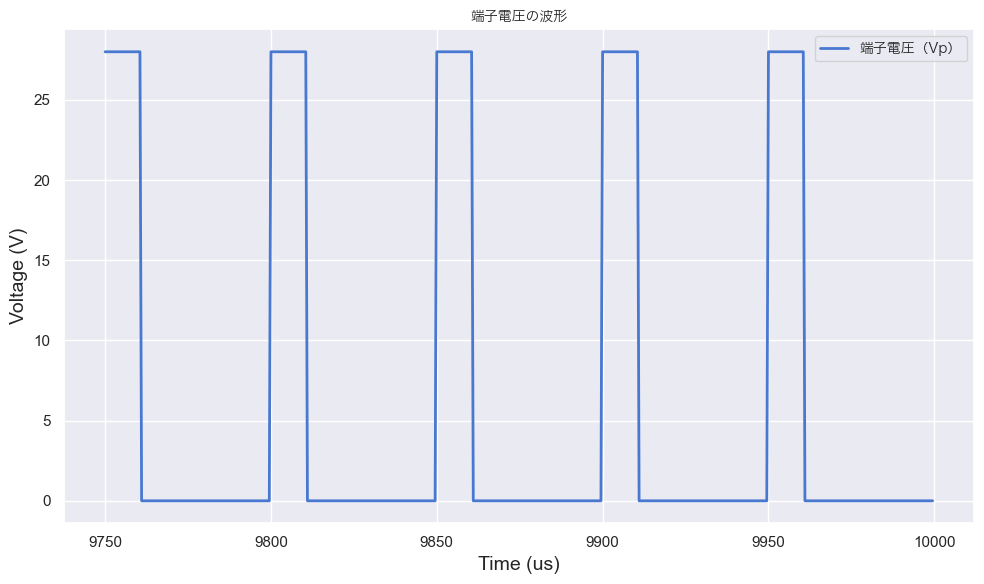

In [4]:
# ================================================
# 入力電圧波形の生成、プロット
# ================================================
def duty_cycle_mod(D0, Vin, dt, Tsim, Ts):
    """
    バックコンバータの変調戦略として
    デューティ比 D0 で方形波を生成し、負部分を 0 にクリップ。
    Vin をかけて端子電圧vpを作る。
    """
    t = np.linspace(0, Ts, round(Ts / dt), endpoint=False)
    s_pri = deque(signal.square(2 * np.pi / Ts * t, D0))
    vp = np.array(s_pri).clip(0, 1) * Vin
    vp = np.tile(vp, (round(Tsim / Ts),))
    return vp


vp = duty_cycle_mod(D0, Vin, dt, Tsim, Ts)
t = np.arange(0, len(vp) * dt, dt)

# 生成したvpをマイクロ秒単位の時間軸でプロット
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))

# 最後の5周期分だけ描画
plt.plot(
    t[-5 * Tslen :] * 1e6,
    vp[-5 * Tslen :],
    label="端子電圧（Vp）",
    color=sns.color_palette("muted")[0],
    linestyle="-",
    linewidth=2,
)
plt.legend(loc="upper right", fontsize=12, prop=font_prop)

plt.title("端子電圧の波形", fontsize=18, weight="bold", fontproperties=font_prop)
plt.xlabel("Time (us)", fontsize=14)
plt.ylabel("Voltage (V)", fontsize=14)

plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
# PANN（後述）への入力は (バッチサイズ×シーケンス長×入力次元) の形式
inputs = vp[None, :, None]  # 1×T×1 の配列に変形
assert inputs.shape == (1, len(vp), 1)
inputs = torch.FloatTensor(inputs)  # Tensor 化

In [6]:

# ＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝====
# PANNによる推論
# ＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝====
class PANN(nn.Module):
    """
    物理内包型アーキテクチャニューラルネットワーク（PANN）
    - EulerCell_Buck: Buck コンバータのオイラー刻みセル
    - Recurrent 構造に物理モデルを組み込み
    """

    def __init__(self, cell, **kwargs):
        super(PANN, self).__init__(**kwargs)
        self.cell = cell

    def forward(self, inputs, x):
        outputs = []
        _x = x[:, 0]  # stateの初期化
        for t in range(inputs.shape[1]):
            state_next = self.cell.forward(inputs[:, t, :], _x)
            _x = state_next  # 予測された状態（state_next）を現在の状態として更新
            outputs.append(_x)  # 予測された状態をoutputsに追加
        return torch.stack(outputs, dim=1)


class EulerCell_Buck(nn.Module):
    """
    従来型のBuckコンバータに対するPANNの陽的オイラーリカレントセルを定義
    """

    def __init__(self, dt, L, Co, Ro, **kwargs):
        super(EulerCell_Buck, self).__init__(**kwargs)
        self.dt = dt
        self.L = nn.Parameter(torch.Tensor([L]))
        self.Co = nn.Parameter(torch.Tensor([Co]))
        self.Ro = nn.Parameter(torch.Tensor([Ro]))

    def forward(self, inputs, states):
        # 陽的オイラー法
        # inputs : s_pri*Vin を表す
        # states : iL, vo を表す
        vo = states[:, 1]
        va = inputs[:, 0]  # 端子電圧
        idx = (inputs[:, 0] == 0) & (states[:, 0] <= 0)  # 離散導通モード（DCM）を評価
        va[idx] = vo[idx]
        iL_next = states[:, 0] + self.dt / self.L * (va - vo)  # iLの物理モデル
        iL_next = torch.relu(iL_next)  # DCMを考慮するためにtorch.reluを適用
        vC_next = states[:, 1] + self.dt / self.Co * (
            states[:, 0] - vo / self.Ro
        )  # vCの物理モデル
        return torch.stack((iL_next, vC_next), dim=1)


# セルとPANNを torch.jit.script でコンパイル（高速化）
# buck_Euler_cell = torch.jit.script(EulerCell_Buck(dt, L, Co, Ro))
# pann_buck = torch.jit.script(PANN(buck_Euler_cell))
buck_Euler_cell = EulerCell_Buck(dt, L, Co, Ro)
pann_buck = PANN(buck_Euler_cell)

# 初期状態（電流iL=0, 出力電圧vo=0）
state0 = torch.zeros((inputs.shape[0], 1, 2))

# 推論実行
pann_buck.eval()
with torch.no_grad():
    states = pann_buck(inputs, state0)
print(states.shape)

torch.Size([1, 20000, 2])


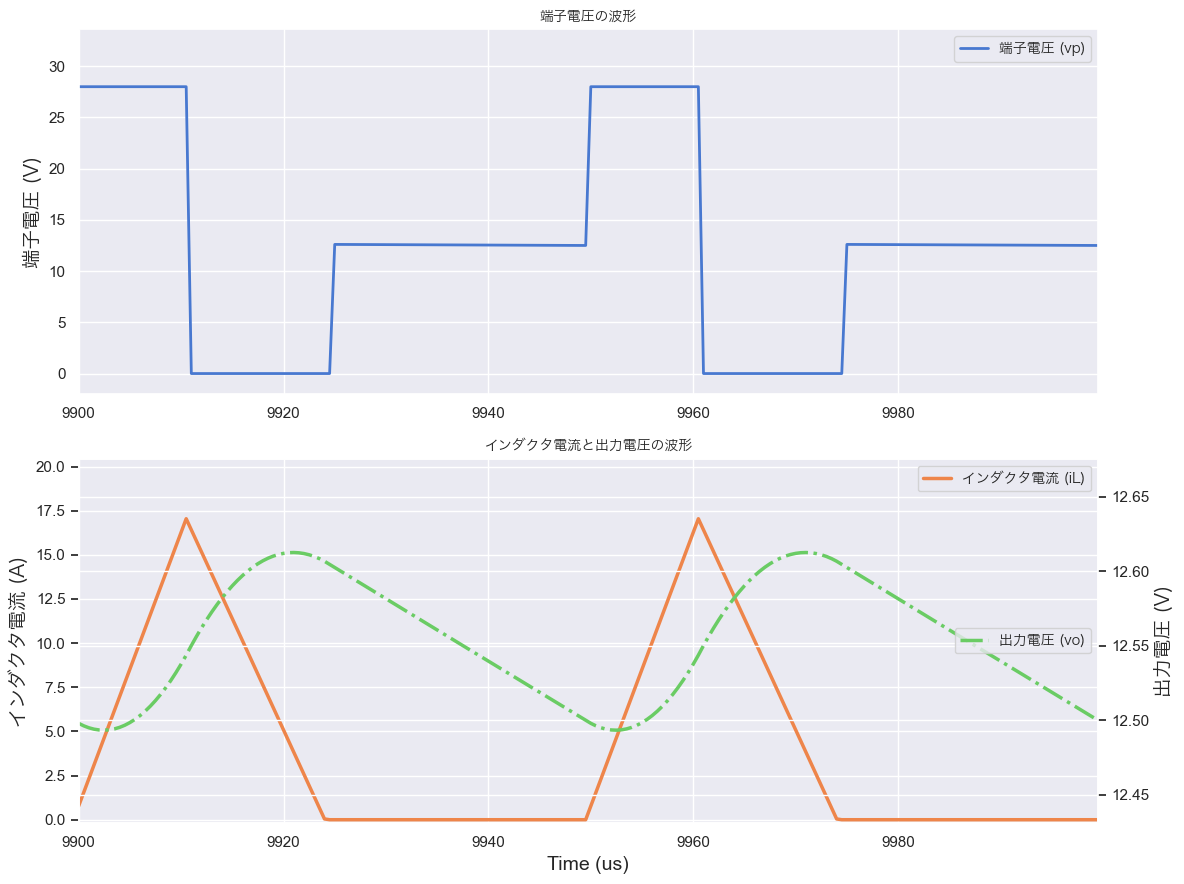

In [8]:
# ================================================
# 推論結果の可視化(最後の2周期分だけ, アニメーションなし)
# ================================================
def plot_results(t, inputs, states, Tslen, font_prop):
    # 最後の2周期分のデータを抽出
    if len(inputs.shape) == 3:
        t = t[-2 * Tslen :] * 1e6
        inputs = inputs[0, -2 * Tslen :]
        states = states[0, -2 * Tslen :]

    t, inputs, states = np.array(t), inputs.numpy(), states.numpy()
    vp, iL, vo = inputs[:, 0], states[:, 0], states[:, 1]

    # プロット設定
    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))
    ax22 = ax2.twinx()

    # 軸の設定
    ax1.set_xlim(t.min(), t.max())
    ax1.set_ylim(-2, inputs.max() * 1.2)
    ax2.set_xlim(t.min(), t.max())
    ax2.set_ylim(-0.2, states[:, 0].max() * 1.2)
    ax22.set_ylim(states[:, 1].min() * 0.995, states[:, 1].max() * 1.005)

    # タイトルとラベル
    ax1.set_title(
        "端子電圧の波形", fontsize=15, weight="bold", fontproperties=font_prop
    )
    ax2.set_title(
        "インダクタ電流と出力電圧の波形",
        fontsize=15,
        weight="bold",
        fontproperties=font_prop,
    )

    ax1.set_ylabel("端子電圧 (V)", fontsize=14, fontproperties=font_prop)
    ax2.set_xlabel("Time (us)", fontsize=14)
    ax2.set_ylabel("インダクタ電流 (A)", fontsize=14, fontproperties=font_prop)
    ax22.set_ylabel("出力電圧 (V)", fontsize=14, fontproperties=font_prop)

    # 波形の描画
    ax1.plot(
        t,
        vp,
        lw=2,
        label="端子電圧 (vp)",
        color=sns.color_palette("muted")[0],
        linestyle="-",
    )

    ax2.plot(
        t,
        iL,
        lw=2.5,
        label="インダクタ電流 (iL)",
        color=sns.color_palette("muted")[1],
        linestyle="-",
    )
    ax22.plot(
        t,
        vo,
        lw=2.5,
        label="出力電圧 (vo)",
        color=sns.color_palette("muted")[2],
        linestyle="-.",
    )

    # グリッドと凡例
    ax1.grid(True)
    ax2.grid(True)
    ax1.legend(loc="upper right", fontsize=12, prop=font_prop)
    ax2.legend(loc="upper right", fontsize=12, prop=font_prop)
    ax22.legend(loc="center right", fontsize=12, prop=font_prop)

    plt.tight_layout()
    plt.show()

plot_results(t, inputs, states, Tslen, font_prop)
